In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# For better visuals
plt.style.use('ggplot')

# Dataset paths
DATASET_PATH = "dataset"
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "valid")
TEST_PATH = os.path.join(DATASET_PATH, "test")

print("Dataset paths set successfully")

Dataset paths set successfully


In [19]:
def count_images(path):
    return len(os.listdir(os.path.join(path, "images")))

def count_labels(path):
    return len(os.listdir(os.path.join(path, "labels")))

train_images = count_images(TRAIN_PATH)
val_images = count_images(VAL_PATH)
test_images = count_images(TEST_PATH)

print("Dataset Summary:")
print(f"Train Images: {train_images}")
print(f"Validation Images: {val_images}")
print(f"Test Images: {test_images}")

Dataset Summary:
Train Images: 322
Validation Images: 92
Test Images: 46


### Dataset Overview

The dataset is divided into training, validation, and test sets.
This helps evaluate how well the model generalizes to unseen data.

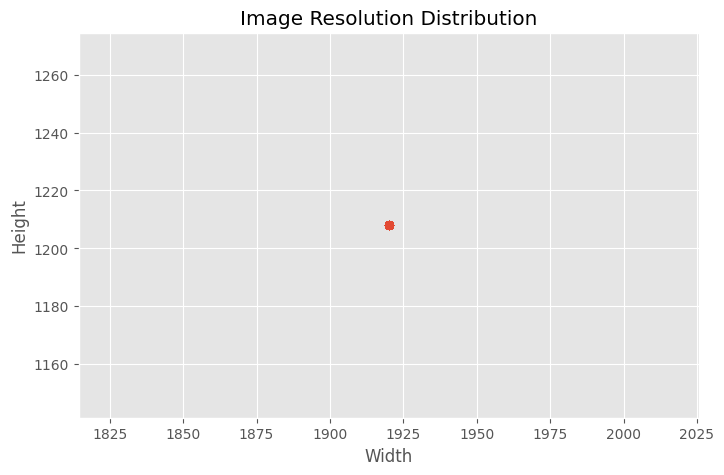

In [20]:
image_sizes = []

image_dir = os.path.join(TRAIN_PATH, "images")

for img_name in os.listdir(image_dir):
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)
    h, w, _ = img.shape
    image_sizes.append((w, h))

widths_img = [s[0] for s in image_sizes]
heights_img = [s[1] for s in image_sizes]

plt.scatter(widths_img, heights_img)
plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

### Image Resolution

- Most images have the same resolution (~1920×1200)
- The dataset is consistent in terms of image size

### Implications:
- Model performance is not affected by varying input resolutions
- However, resizing images during training (e.g., 640 vs 1024) plays a key role in detecting small objects

In [21]:
def show_image_with_boxes(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())

                # Convert YOLO format → pixel coords
                x1 = int((x - bw / 2) * w)
                y1 = int((y - bh / 2) * h)
                x2 = int((x + bw / 2) * w)
                y2 = int((y + bh / 2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

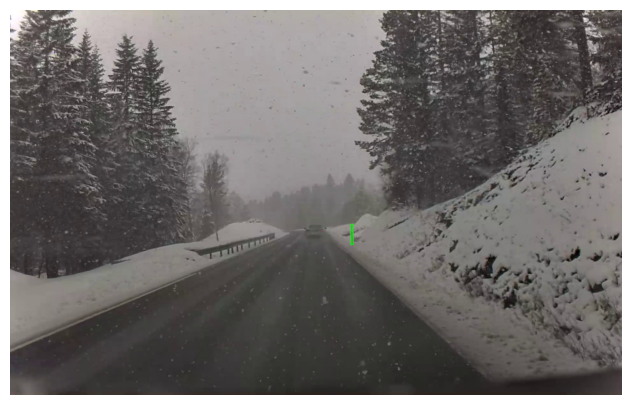

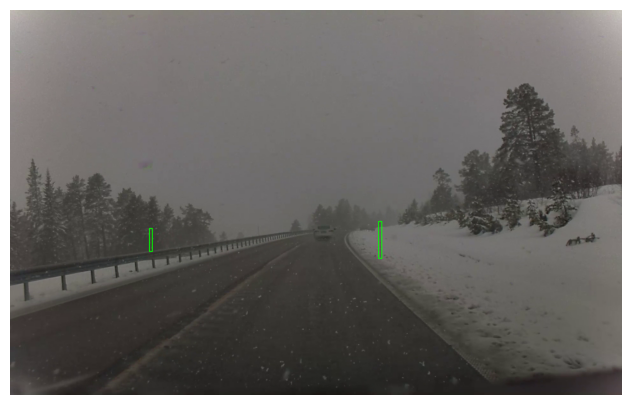

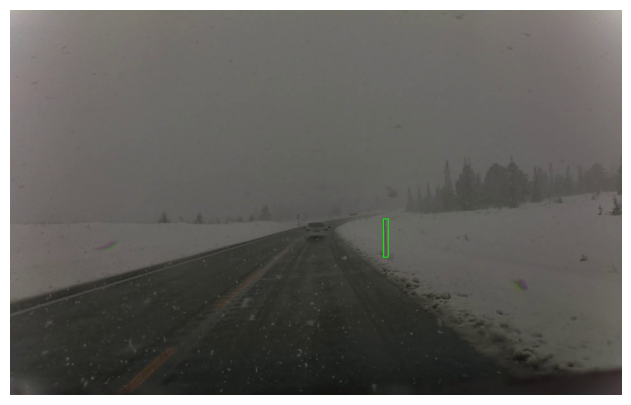

In [22]:
import random

image_dir = os.path.join(TRAIN_PATH, "images")
label_dir = os.path.join(TRAIN_PATH, "labels")

images = [f for f in os.listdir(image_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]

sample_images = random.sample(images, 3)

for img_name in sample_images:
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")

    show_image_with_boxes(img_path, label_path)

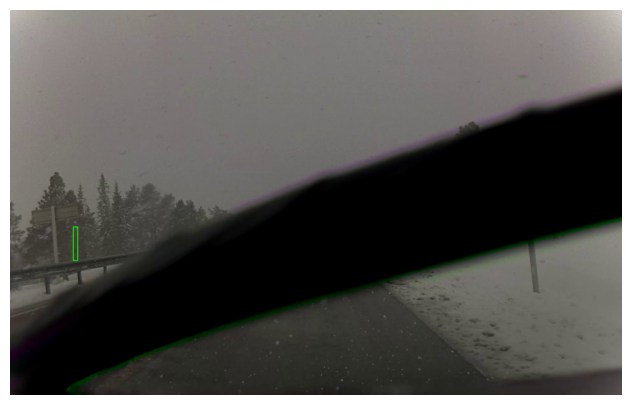

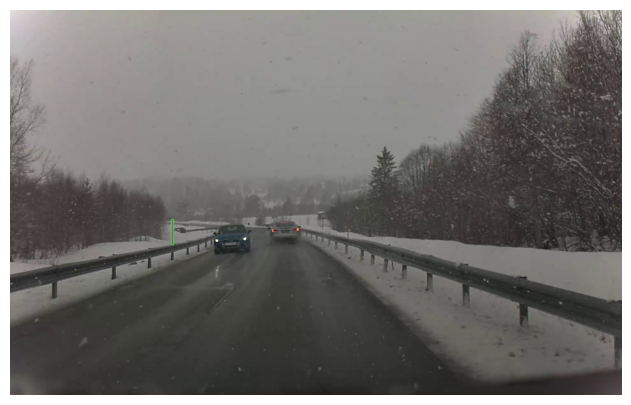

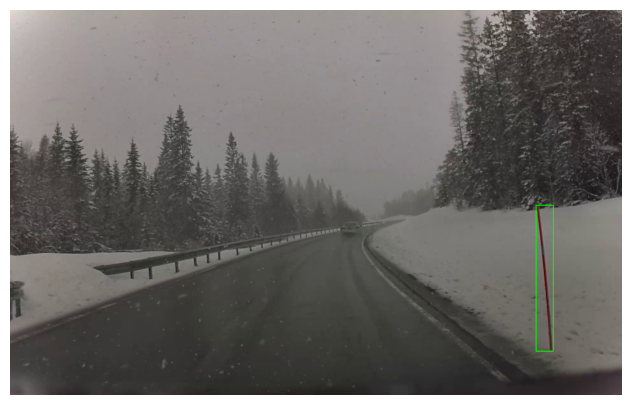

In [23]:
small_indices = np.argsort(areas)[:3]

files = list(os.listdir(label_dir))

for idx in small_indices:
    file = files[idx]
    img_name = file.replace(".txt", ".PNG")
    
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, file)

    show_image_with_boxes(img_path, label_path)

In [24]:
widths = []
heights = []

label_dir = os.path.join(TRAIN_PATH, "labels")

for file in os.listdir(label_dir):
    if not file.endswith(".txt"):
        continue

    with open(os.path.join(label_dir, file)) as f:
        for line in f:
            _, _, _, w, h = map(float, line.split())
            widths.append(w)
            heights.append(h)

print(f"Total boxes: {len(widths)}")

Total boxes: 392


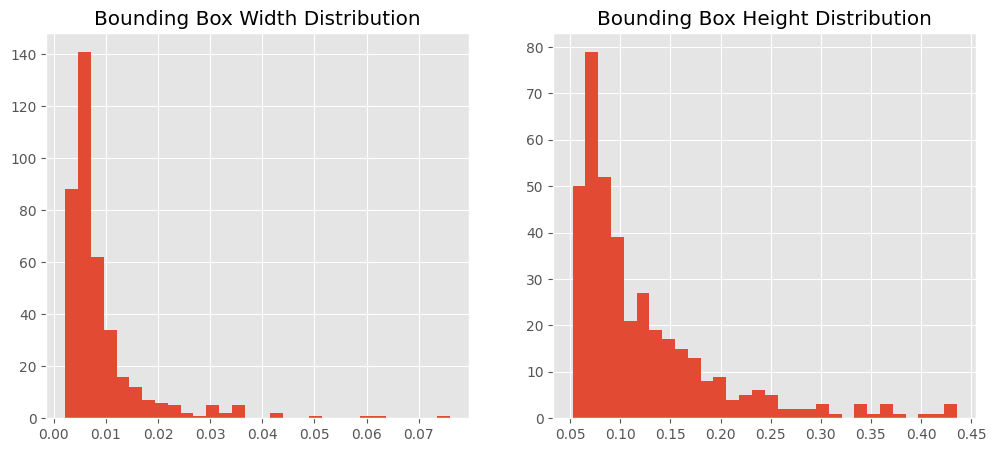

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title("Bounding Box Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title("Bounding Box Height Distribution")

plt.show()

### Bounding Box Analysis

- Bounding box widths are extremely small, indicating that objects occupy a very small horizontal portion of the image  
- Heights are significantly larger than widths, confirming that objects are vertically elongated  
- This results in a high aspect ratio for most objects  

### Implications:
- Detecting such thin objects is challenging for object detection models  
- Small object size makes localization difficult  
- Higher image resolution improves detection performance  

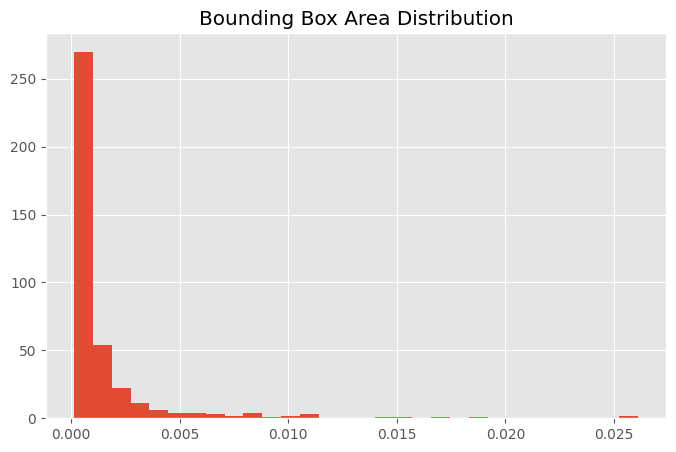

In [26]:
areas = [w * h for w, h in zip(widths, heights)]

plt.hist(areas, bins=30)
plt.title("Bounding Box Area Distribution")
plt.show()

### Bounding Box Area

- Most bounding boxes have extremely small area relative to the image
- This confirms that the dataset consists of very small objects

### Implications:
- Detecting such small objects is challenging
- Higher resolution inputs improve detection performance
- Models may struggle with localization and recall

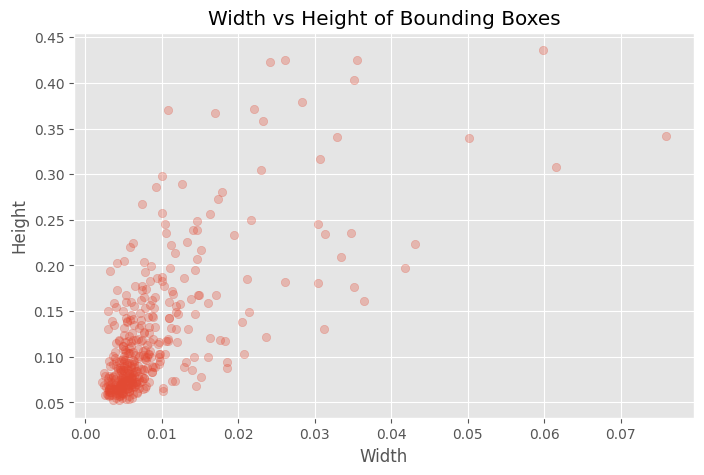

In [29]:
plt.scatter(widths, heights, alpha=0.3)
plt.title("Width vs Height of Bounding Boxes")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

### Width vs Height Relationship

- Most bounding boxes are concentrated in a region of very small width and moderate height  
- There is a positive relationship between width and height, but width remains significantly smaller  

### Key Observations:
- Objects are consistently thin and vertically elongated  
- Majority of detections involve small and narrow structures  
- A few larger boxes correspond to closer or more visible poles  

### Implications:
- Detecting such thin objects is challenging for object detection models  
- Localization errors are more likely due to small width  
- Models benefit from higher resolution inputs to capture fine details  

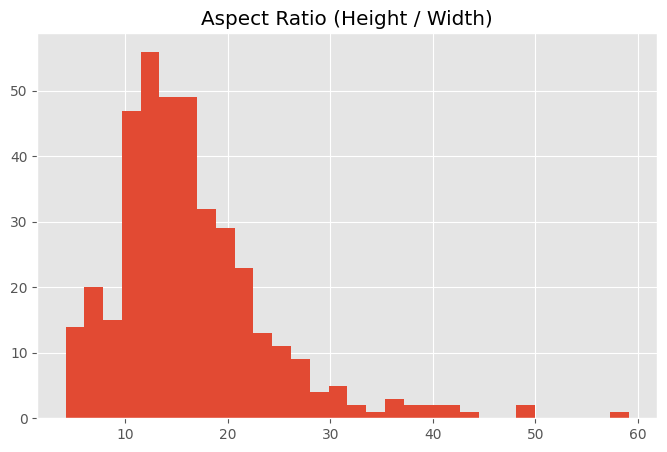

In [27]:
ratios = [h / w for h, w in zip(heights, widths) if w > 0]

plt.hist(ratios, bins=30)
plt.title("Aspect Ratio (Height / Width)")
plt.show()

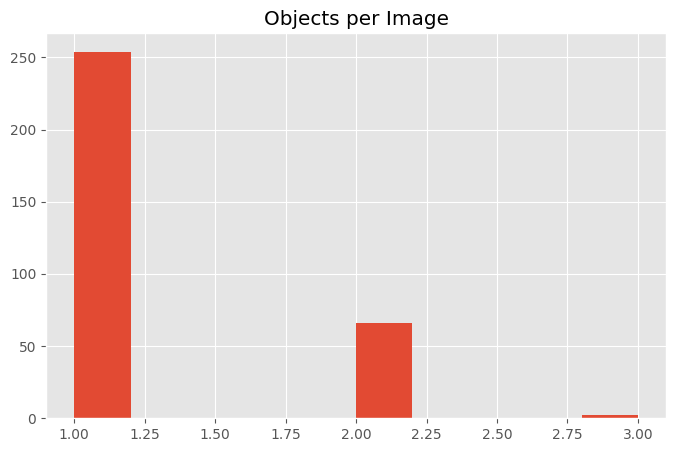

In [28]:
counts = []

for file in os.listdir(label_dir):
    if not file.endswith(".txt"):
        continue

    with open(os.path.join(label_dir, file)) as f:
        counts.append(len(f.readlines()))

plt.hist(counts, bins=10)
plt.title("Objects per Image")
plt.show()

### Aspect Ratio Analysis

- Most objects have very high aspect ratios (10–20+)
- This confirms that snow poles are thin and vertically elongated structures

### Object Density

- Most images contain only one object
- Very few images contain multiple poles
- This indicates a sparse detection setting

### Implications for Detection

- Small object size makes detection challenging
- High aspect ratio objects are harder to localize accurately
- Sparse scenes require models to be sensitive to small features

These characteristics explain:
- Why higher resolution improves YOLO performance
- Why RCNN struggles with recall

## Final Observations

Based on the exploratory analysis of the dataset:

### Dataset Characteristics
- The dataset contains a relatively small number of images  
- Objects (snow poles) are small relative to image size  
- Objects are thin and vertically elongated (high aspect ratio)  
- Most images contain only one object → sparse distribution  

### Challenges in the Dataset
- Small object detection is inherently difficult  
- High aspect ratio objects are harder to localize  
- Sparse scenes require models to detect subtle features  

### Conclusion
This dataset presents a challenging object detection problem due to:
- small object size  
- thin structures  
- low object density  

These characteristics must be considered when choosing models and training strategies.